# LIAR - Baseline Classifiers
**Notebook 02: misinformation classification**

This notebook supports **Objective 3.1.2** of the dissertation: train and benchmark transformer classifiers for binary misinformation detection on LIAR, using a fixed protocol that the rest of the dissertation will refer back to.

What "fixed protocol" means here:

- A single binarisation (the conservative one validated in Notebook 01).
- A single set of hyperparameters chosen up front, not tuned on the test set.
- Three random seeds per model so we can report **mean ± std**, not a single lucky run.
- All metrics - accuracy, precision, recall, F1, per-class confusion - computed on the held-out *test* split.
- Classical baselines (majority class, TF-IDF + Logistic Regression) reported alongside as a floor for the transformers to clear.

The test-set predictions are saved at the end so Notebook 03 (the diagnostic) can correlate them with the affective features we characterised in Notebook 01.


In [1]:
# Install dependencies (Colab)
!pip install -q transformers scikit-learn pandas seaborn matplotlib


In [2]:
import os, io, math, json, time, zipfile, urllib.request, warnings, random, inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    set_seed,
)
import transformers
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 140)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch device:", DEVICE)
print("transformers version:", transformers.__version__)
if DEVICE.type != "cuda":
    print("WARNING: no GPU detected. Training will be slow.")


torch device: cuda
transformers version: 5.0.0


## 1. Load LIAR

In [3]:
LIAR_URL = "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"
LIAR_DIR = "/content/liar_raw"

if not os.path.isdir(LIAR_DIR) or not os.path.exists(f"{LIAR_DIR}/train.tsv"):
    os.makedirs(LIAR_DIR, exist_ok=True)
    print("Downloading LIAR from UCSB...")
    with urllib.request.urlopen(LIAR_URL) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall(LIAR_DIR)
    print("Done. Files:", sorted(os.listdir(LIAR_DIR)))
else:
    print("LIAR already downloaded.")

LIAR_COLS = [
    "id","label","statement","subject","speaker","job_title",
    "state_info","party_affiliation",
    "barely_true_counts","false_counts","half_true_counts",
    "mostly_true_counts","pants_on_fire_counts","context",
]

def load_tsv(path):
    return pd.read_csv(path, sep="\t", names=LIAR_COLS, quoting=3)

train = load_tsv(f"{LIAR_DIR}/train.tsv")
val   = load_tsv(f"{LIAR_DIR}/valid.tsv")
test  = load_tsv(f"{LIAR_DIR}/test.tsv")

for df in (train, val, test):
    df["label_name"] = df["label"].astype(str)

print(f"sizes  train={len(train):>5}  val={len(val):>5}  test={len(test):>5}")


Done. Files: ['README', 'test.tsv', 'train.tsv', 'valid.tsv']
sizes  train=10269  val= 1284  test= 1283


## 2. Binarise (conservative mapping)

In [4]:
BINARY_MAP = {
    "pants-fire": 1, "false": 1, "barely-true": 1,
    "half-true": 0, "mostly-true": 0, "true": 0,
}
for df in (train, val, test):
    df["y"] = df["label_name"].map(BINARY_MAP)

print("Class balance:")
for name, df in [("train", train), ("val", val), ("test", test)]:
    n0 = int((df["y"]==0).sum()); n1 = int((df["y"]==1).sum())
    print(f"  {name:<5}  factual={n0:>4}  misinformation={n1:>4}  (n={n0+n1})")


Class balance:
  train  factual=5772  misinformation=4497  (n=10269)
  val    factual= 668  misinformation= 616  (n=1284)
  test   factual= 727  misinformation= 556  (n=1283)


## 3. Classical baselines

Two reference points the transformers need to beat for the dissertation to claim they're contributing anything:

- **Majority class** - predict `factual` for every test instance.
- **TF-IDF + Logistic Regression** - word unigrams and bigrams, L2-regularised logistic regression.

In [5]:
def score(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {"model": name, "seed": None,
            "accuracy": acc, "precision": p, "recall": r, "f1": f1,
            "confusion_matrix": cm}

maj_pred = np.zeros(len(test), dtype=int)
maj_metrics = score(test["y"].values, maj_pred, "majority_class")

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=20000)
X_train = tfidf.fit_transform(train["statement"].astype(str))
X_test  = tfidf.transform(test["statement"].astype(str))
lr = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
lr.fit(X_train, train["y"])
lr_pred  = lr.predict(X_test)
lr_metrics = score(test["y"].values, lr_pred, "tfidf_logreg")

classical_df = pd.DataFrame([
    {k: v for k, v in m.items() if k != "confusion_matrix"} for m in [maj_metrics, lr_metrics]
])
print("Classical baselines on test split:")
print(classical_df.round(4).to_string(index=False))


Classical baselines on test split:
         model seed  accuracy  precision  recall     f1
majority_class None    0.5666     0.0000  0.0000 0.0000
  tfidf_logreg None    0.6282     0.5971  0.4371 0.5047


## 4. Transformer fine-tuning - function definition

The training protocol is fixed: max sequence length 128, AdamW lr=2e-5, batch 32 train / 64 eval, 3 epochs, warmup 10%, weight decay 0.01, FP16 on GPU, per-epoch eval on validation.

`make_training_args` constructs `TrainingArguments` *defensively* - it introspects which parameter names the installed `transformers` version accepts and silently drops anything that has been renamed or removed. This avoids breakage across HuggingFace API churn (e.g. the `evaluation_strategy` → `eval_strategy` rename, and the more recent removal of `overwrite_output_dir`).

In [6]:
def make_training_args(**kwargs):
    """Build TrainingArguments, tolerating cross-version parameter churn."""
    sig = inspect.signature(TrainingArguments.__init__)
    valid = set(sig.parameters.keys())

    # eval_strategy was added in newer transformers; older releases use evaluation_strategy.
    if "eval_strategy" in kwargs and "eval_strategy" not in valid and "evaluation_strategy" in valid:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    elif "evaluation_strategy" in kwargs and "evaluation_strategy" not in valid and "eval_strategy" in valid:
        kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")

    # Drop any kwargs the current version doesn't recognise.
    filtered = {k: v for k, v in kwargs.items() if k in valid}
    dropped = sorted(set(kwargs) - set(filtered))
    if dropped:
        print(f"  [make_training_args] dropping unsupported kwargs: {dropped}")
    return TrainingArguments(**filtered)


class LiarDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.enc = tokenizer(
            list(texts.astype(str)),
            padding=False, truncation=True, max_length=max_length,
        )
        self.labels = [int(x) for x in labels]
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    return {"accuracy": accuracy_score(labels, preds),
            "precision": p, "recall": r, "f1": f1}


def run_finetune(model_name, seed,
                 train_df, val_df, test_df,
                 epochs=3, lr=2e-5, max_length=128,
                 train_bs=32, eval_bs=64):
    set_seed(seed)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds = LiarDataset(train_df["statement"], train_df["y"], tokenizer, max_length)
    val_ds   = LiarDataset(val_df["statement"],   val_df["y"],   tokenizer, max_length)
    test_ds  = LiarDataset(test_df["statement"],  test_df["y"],  tokenizer, max_length)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    args = make_training_args(
        output_dir=f"/tmp/run_{model_name.replace('/','_')}_seed{seed}",
        num_train_epochs=epochs,
        learning_rate=lr,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        seed=seed,
        fp16=torch.cuda.is_available(),
        report_to="none",
        disable_tqdm=True,
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=hf_compute_metrics,
        data_collator=DataCollatorWithPadding(tokenizer),
    )

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    test_out = trainer.predict(test_ds)
    logits = test_out.predictions
    preds  = logits.argmax(axis=-1)
    labels = test_out.label_ids

    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    return {
        "model": model_name, "seed": seed,
        "accuracy": accuracy_score(labels, preds),
        "precision": p, "recall": r, "f1": f1,
        "confusion_matrix": confusion_matrix(labels, preds, labels=[0,1]),
        "test_logits": logits, "test_preds": preds, "test_labels": labels,
        "train_time_s": train_time,
    }


## 5. BERT × 3 seeds

In [7]:
SEEDS = [42, 1337, 2024]
MODEL_BERT = "bert-base-uncased"

bert_runs = []
for seed in SEEDS:
    print(f"\n=== {MODEL_BERT} seed={seed} ===")
    r = run_finetune(MODEL_BERT, seed, train, val, test)
    bert_runs.append(r)
    print(f"  test  acc={r['accuracy']:.4f}  P={r['precision']:.4f}  "
          f"R={r['recall']:.4f}  F1={r['f1']:.4f}  ({r['train_time_s']:.0f}s)")



=== bert-base-uncased seed=42 ===


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

{'loss': '0.6632', 'grad_norm': '1.884', 'learning_rate': '1.485e-05', 'epoch': '1'}
{'eval_loss': '0.6466', 'eval_accuracy': '0.6262', 'eval_precision': '0.6435', 'eval_recall': '0.4951', 'eval_f1': '0.5596', 'eval_runtime': '1.131', 'eval_samples_per_second': '1135', 'eval_steps_per_second': '18.56', 'epoch': '1'}
{'loss': '0.6026', 'grad_norm': '5.385', 'learning_rate': '7.436e-06', 'epoch': '2'}
{'eval_loss': '0.6732', 'eval_accuracy': '0.6269', 'eval_precision': '0.6717', 'eval_recall': '0.4351', 'eval_f1': '0.5281', 'eval_runtime': '1.011', 'eval_samples_per_second': '1270', 'eval_steps_per_second': '20.77', 'epoch': '2'}
{'loss': '0.5132', 'grad_norm': '5.123', 'learning_rate': '2.309e-08', 'epoch': '3'}
{'eval_loss': '0.6923', 'eval_accuracy': '0.6277', 'eval_precision': '0.6386', 'eval_recall': '0.5162', 'eval_f1': '0.5709', 'eval_runtime': '1.014', 'eval_samples_per_second': '1266', 'eval_steps_per_second': '20.7', 'epoch': '3'}
{'train_runtime': '125.7', 'train_samples_per_s

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

{'loss': '0.6666', 'grad_norm': '3.064', 'learning_rate': '1.485e-05', 'epoch': '1'}
{'eval_loss': '0.6758', 'eval_accuracy': '0.5685', 'eval_precision': '0.7214', 'eval_recall': '0.164', 'eval_f1': '0.2672', 'eval_runtime': '1.007', 'eval_samples_per_second': '1275', 'eval_steps_per_second': '20.86', 'epoch': '1'}
{'loss': '0.6112', 'grad_norm': '4.51', 'learning_rate': '7.436e-06', 'epoch': '2'}
{'eval_loss': '0.6413', 'eval_accuracy': '0.6277', 'eval_precision': '0.6211', 'eval_recall': '0.5747', 'eval_f1': '0.597', 'eval_runtime': '1.022', 'eval_samples_per_second': '1256', 'eval_steps_per_second': '20.55', 'epoch': '2'}
{'loss': '0.5139', 'grad_norm': '5.331', 'learning_rate': '2.309e-08', 'epoch': '3'}
{'eval_loss': '0.7072', 'eval_accuracy': '0.6199', 'eval_precision': '0.629', 'eval_recall': '0.5065', 'eval_f1': '0.5612', 'eval_runtime': '1.017', 'eval_samples_per_second': '1262', 'eval_steps_per_second': '20.65', 'epoch': '3'}
{'train_runtime': '109.2', 'train_samples_per_seco

## 6. Aggregate BERT results

In [8]:
def runs_to_df(runs):
    return pd.DataFrame([{
        "model": r["model"], "seed": r["seed"],
        "accuracy": r["accuracy"], "precision": r["precision"],
        "recall":   r["recall"],   "f1":        r["f1"],
        "train_time_s": r["train_time_s"],
    } for r in runs])

bert_df = runs_to_df(bert_runs)
print("Per-seed test metrics:")
print(bert_df.round(4).to_string(index=False))

bert_agg = bert_df.agg(
    {"accuracy":["mean","std"], "precision":["mean","std"],
     "recall":["mean","std"], "f1":["mean","std"]}
).round(4)
print("\nAggregated (across seeds):")
print(bert_agg.T)


Per-seed test metrics:
            model  seed  accuracy  precision  recall     f1  train_time_s
bert-base-uncased    42    0.6368     0.6000  0.4856 0.5368      112.8056
bert-base-uncased  1337    0.6438     0.6098  0.4946 0.5462      126.2152
bert-base-uncased  2024    0.6352     0.5936  0.5018 0.5439      109.7379

Aggregated (across seeds):
             mean     std
accuracy   0.6386  0.0046
precision  0.6011  0.0081
recall     0.4940  0.0081
f1         0.5423  0.0049


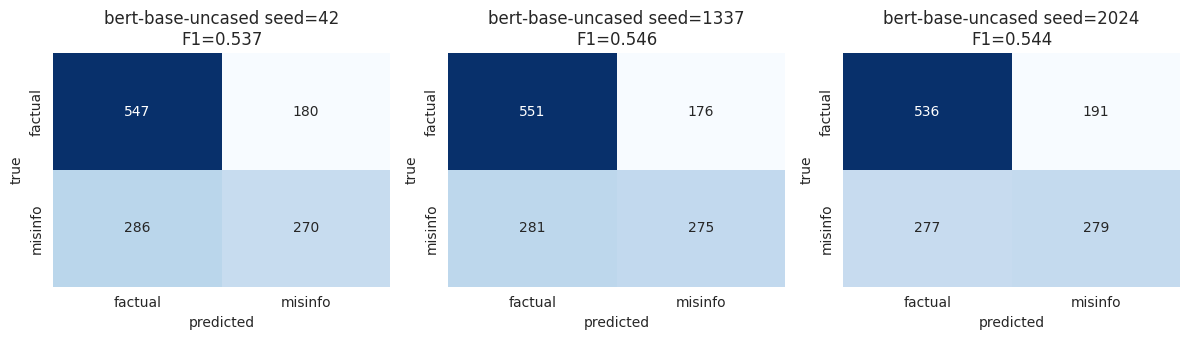

In [9]:
fig, axes = plt.subplots(1, len(bert_runs), figsize=(4*len(bert_runs), 3.5))
if len(bert_runs) == 1:
    axes = [axes]
for ax, r in zip(axes, bert_runs):
    sns.heatmap(r["confusion_matrix"], annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["factual","misinfo"],
                yticklabels=["factual","misinfo"], cbar=False)
    ax.set_title(f"{r['model']} seed={r['seed']}\nF1={r['f1']:.3f}")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()


### How to read these numbers

- **Beat the classical baselines.** BERT should clear majority-class (≈0.57 accuracy on this binarisation) comfortably, and should clear TF-IDF + LogReg by at least a couple of F1 points.
- **Variance across seeds matters as much as the mean.** If F1 swings more than ~3 points between seeds, the dissertation has to quote mean ± std and acknowledge initialisation-dependence.
- **Confusion matrices.** Imbalances between false-positive and false-negative rates are themselves a finding and an entry point for the diagnostic in Notebook 03.

## 7. (Optional) RoBERTa × 3 seeds

Skip if short on Colab GPU time; this adds ~15 minutes.

In [10]:
MODEL_ROBERTA = "roberta-base"

roberta_runs = []
for seed in SEEDS:
    print(f"\n=== {MODEL_ROBERTA} seed={seed} ===")
    r = run_finetune(MODEL_ROBERTA, seed, train, val, test)
    roberta_runs.append(r)
    print(f"  test  acc={r['accuracy']:.4f}  P={r['precision']:.4f}  "
          f"R={r['recall']:.4f}  F1={r['f1']:.4f}  ({r['train_time_s']:.0f}s)")



=== roberta-base seed=42 ===


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '0.6675', 'grad_norm': '2.613', 'learning_rate': '1.485e-05', 'epoch': '1'}
{'eval_loss': '0.6595', 'eval_accuracy': '0.6051', 'eval_precision': '0.6811', 'eval_recall': '0.3328', 'eval_f1': '0.4471', 'eval_runtime': '0.9466', 'eval_samples_per_second': '1356', 'eval_steps_per_second': '22.18', 'epoch': '1'}
{'loss': '0.6178', 'grad_norm': '6.63', 'learning_rate': '7.436e-06', 'epoch': '2'}
{'eval_loss': '0.6534', 'eval_accuracy': '0.6526', 'eval_precision': '0.7261', 'eval_recall': '0.4432', 'eval_f1': '0.5504', 'eval_runtime': '0.9349', 'eval_samples_per_second': '1373', 'eval_steps_per_second': '22.46', 'epoch': '2'}
{'loss': '0.5476', 'grad_norm': '9.986', 'learning_rate': '2.309e-08', 'epoch': '3'}
{'eval_loss': '0.6635', 'eval_accuracy': '0.6628', 'eval_precision': '0.6993', 'eval_recall': '0.5211', 'eval_f1': '0.5972', 'eval_runtime': '0.9359', 'eval_samples_per_second': '1372', 'eval_steps_per_second': '22.44', 'epoch': '3'}
{'train_runtime': '104.3', 'train_samples_pe

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '0.6681', 'grad_norm': '4.277', 'learning_rate': '1.485e-05', 'epoch': '1'}
{'eval_loss': '0.6749', 'eval_accuracy': '0.5662', 'eval_precision': '0.7565', 'eval_recall': '0.1412', 'eval_f1': '0.238', 'eval_runtime': '0.9462', 'eval_samples_per_second': '1357', 'eval_steps_per_second': '22.19', 'epoch': '1'}
{'loss': '0.6221', 'grad_norm': '6.392', 'learning_rate': '7.436e-06', 'epoch': '2'}
{'eval_loss': '0.6395', 'eval_accuracy': '0.6433', 'eval_precision': '0.6985', 'eval_recall': '0.4513', 'eval_f1': '0.5483', 'eval_runtime': '0.9476', 'eval_samples_per_second': '1355', 'eval_steps_per_second': '22.16', 'epoch': '2'}
{'loss': '0.5477', 'grad_norm': '8.251', 'learning_rate': '2.309e-08', 'epoch': '3'}
{'eval_loss': '0.6681', 'eval_accuracy': '0.6651', 'eval_precision': '0.7004', 'eval_recall': '0.5276', 'eval_f1': '0.6019', 'eval_runtime': '0.9618', 'eval_samples_per_second': '1335', 'eval_steps_per_second': '21.83', 'epoch': '3'}
{'train_runtime': '104.1', 'train_samples_pe

In [11]:
if roberta_runs:
    roberta_df = runs_to_df(roberta_runs)
    print("RoBERTa per-seed test metrics:")
    print(roberta_df.round(4).to_string(index=False))

    roberta_agg = roberta_df.agg(
        {"accuracy":["mean","std"], "precision":["mean","std"],
         "recall":["mean","std"], "f1":["mean","std"]}
    ).round(4)
    print("\nAggregated (across seeds):")
    print(roberta_agg.T)


RoBERTa per-seed test metrics:
       model  seed  accuracy  precision  recall     f1  train_time_s
roberta-base    42    0.6586     0.6300  0.5144 0.5663      104.3900
roberta-base  1337    0.6454     0.6188  0.4730 0.5362      104.7494
roberta-base  2024    0.6602     0.6471  0.4748 0.5477      104.6303

Aggregated (across seeds):
             mean     std
accuracy   0.6547  0.0081
precision  0.6319  0.0142
recall     0.4874  0.0234
f1         0.5501  0.0152


## 8. Side-by-side summary

In [12]:
rows = []
rows.append({**{k: maj_metrics[k] for k in ["model","accuracy","precision","recall","f1"]},
             "seed": "-", "kind": "classical"})
rows.append({**{k: lr_metrics[k]  for k in ["model","accuracy","precision","recall","f1"]},
             "seed": "-", "kind": "classical"})
for r in bert_runs:
    rows.append({"model": r["model"], "seed": str(r["seed"]),
                 "accuracy": r["accuracy"], "precision": r["precision"],
                 "recall": r["recall"], "f1": r["f1"], "kind": "transformer"})
for r in roberta_runs:
    rows.append({"model": r["model"], "seed": str(r["seed"]),
                 "accuracy": r["accuracy"], "precision": r["precision"],
                 "recall": r["recall"], "f1": r["f1"], "kind": "transformer"})

summary = pd.DataFrame(rows)[["kind","model","seed","accuracy","precision","recall","f1"]]
print(summary.round(4).to_string(index=False))


       kind             model seed  accuracy  precision  recall     f1
  classical    majority_class    -    0.5666     0.0000  0.0000 0.0000
  classical      tfidf_logreg    -    0.6282     0.5971  0.4371 0.5047
transformer bert-base-uncased   42    0.6368     0.6000  0.4856 0.5368
transformer bert-base-uncased 1337    0.6438     0.6098  0.4946 0.5462
transformer bert-base-uncased 2024    0.6352     0.5936  0.5018 0.5439
transformer      roberta-base   42    0.6586     0.6300  0.5144 0.5663
transformer      roberta-base 1337    0.6454     0.6188  0.4730 0.5362
transformer      roberta-base 2024    0.6602     0.6471  0.4748 0.5477


## 9. Save artefacts

In [13]:
OUT = "/content/liar_baseline_artifacts"
os.makedirs(OUT, exist_ok=True)

def save_preds(r, test_df):
    name = f"{r['model'].replace('/','_')}_seed{r['seed']}"
    probs = torch.softmax(torch.from_numpy(r["test_logits"]), dim=-1).numpy()
    df = pd.DataFrame({
        "id":            test_df["id"].values,
        "label_name":    test_df["label_name"].values,
        "y_true":        r["test_labels"],
        "y_pred":        r["test_preds"],
        "prob_factual":  probs[:, 0],
        "prob_misinfo":  probs[:, 1],
        "logit_factual": r["test_logits"][:, 0],
        "logit_misinfo": r["test_logits"][:, 1],
    })
    df.to_parquet(f"{OUT}/preds_{name}.parquet", index=False)
    return f"preds_{name}.parquet"

saved = []
for r in bert_runs + roberta_runs:
    saved.append(save_preds(r, test))

summary.to_csv(f"{OUT}/all_runs_summary.csv", index=False)
runs_to_df(bert_runs).to_csv(f"{OUT}/bert_per_seed.csv", index=False)
if roberta_runs:
    runs_to_df(roberta_runs).to_csv(f"{OUT}/roberta_per_seed.csv", index=False)

with open(f"{OUT}/run_meta.json", "w") as f:
    json.dump({
        "transformers_version": transformers.__version__,
        "seeds": SEEDS,
        "binary_map": BINARY_MAP,
        "training": {
            "epochs": 3, "lr": 2e-5, "max_length": 128,
            "train_bs": 32, "eval_bs": 64,
            "warmup_ratio": 0.1, "weight_decay": 0.01,
            "fp16": torch.cuda.is_available(),
        },
        "models": list({r["model"] for r in bert_runs + roberta_runs}),
        "device": str(DEVICE),
        "n_train": int(len(train)), "n_val": int(len(val)), "n_test": int(len(test)),
    }, f, indent=2)

print("Saved prediction files:")
for fn in sorted(saved): print(" ", fn)
print("\nFull directory:")
for fn in sorted(os.listdir(OUT)): print(" ", fn)


Saved prediction files:
  preds_bert-base-uncased_seed1337.parquet
  preds_bert-base-uncased_seed2024.parquet
  preds_bert-base-uncased_seed42.parquet
  preds_roberta-base_seed1337.parquet
  preds_roberta-base_seed2024.parquet
  preds_roberta-base_seed42.parquet

Full directory:
  all_runs_summary.csv
  bert_per_seed.csv
  preds_bert-base-uncased_seed1337.parquet
  preds_bert-base-uncased_seed2024.parquet
  preds_bert-base-uncased_seed42.parquet
  preds_roberta-base_seed1337.parquet
  preds_roberta-base_seed2024.parquet
  preds_roberta-base_seed42.parquet
  roberta_per_seed.csv
  run_meta.json
